In [2]:
plan = """
ablation with svd
rationale is like this: 
- if an agent functions as intended, on average, the steps will be fine. error steps are like an OOD event, an anomoly. therefore, we may detect OOD by calculating the distance between a step from the average.
- each agent has its own distribution. it would be better if i just calculate "distance" within an agent distribution, instead of over all agents. For example, gathering all steps from Orchestrator / Websurfer and do analysis on them.

data preparation:
[ ] collect all steps from a subset
[ ] stratify those steps to collections of steps w.r.t agents.

computation:
inference: `score = ⟨g, v⟩²`, in which the general designs are:
	`g` is the representation of a particular step. in SAL, `g` is the centered gradient computed from NTP loss. 
	`v` is the representation of the "abnormal" direction. in SAL, `v` is the first principal vector from matrix `G` fo centered gradients, which 
	`⟨g, v⟩²` is the L2-norm of the `g` projected onto the outlier direction `v`. the higher, the more likely it is the error/abnormal step. 
one remark: `|g|²` is the L2-norm of the (centered ?) gradient. This is different from GradNorm, which only computes the L2/L1-norm of raw gradients. This is, for some reasons, not ablated in the SAL work.

stratified steps:
	- select an agent (Orchestrator / Websurfer)
	- for each agent, compute its respective `v`. something like `V(g)`.
	-  `score = ⟨g, v⟩²` is done 
---
+) how many steps should i select?
+) which weight is the most suitable?
+) should i use reference gradient or not?

for the following ablations:
- i will precompute gradients for all steps. all the following computation can be done upon those gradients. 
- i will select the top 5 most informative weights from gradnorm ablation studies due to the memory complexity.
- choose NLP loss as signal.

[ ] (only on hand-crafted) ablate agent-agnostic / agent-conditional SVD. for agent-agnostic, select one principal component for all steps. for agent-conditional, for each agent, select a different principal component.
[ ] ablate w/ and wo/ the ref gradient. this should be carried at the same time as wild gradient selection.
[ ] (with best principal component design) ablate number of wild gradients: iterate thru [20, 40, 60, 80, 100] % of all samples for SVD decomposition. 
[ ] ablate different number of components in SVD: with best (number of wild gradients, presence of ref gradient) configuration, test different number of components.
[ ] ablate weights: if i have enough time and compute, i wll do this. 
"""

In [1]:
import torch
t = torch.rand(3000, 4000000, dtype=torch.float16)
print(t.shape, t.dtype, f"{t.numel()*4/1e9:.2f} GB")

: 

In [ ]:
from __future__ import annotations
 
import argparse
import json
from dataclasses import dataclass, field
from pathlib import Path
 
import torch
import numpy as np
from tqdm import tqdm
 
 
# ─────────────────────────────────────────────────────────────────────────────
# Data structures
# ─────────────────────────────────────────────────────────────────────────────
 
@dataclass
class StepIndex:
    """Row-level metadata for one entry in the stacked gradient matrix."""
    row:        int     # row index in G
    traj_idx:   int     # index into the loaded data list
    step_idx:   int     # step index within the trajectory
    is_mistake: bool    # whether this is the gold mistake step
 
 
@dataclass
class GradientStore:
    G:           torch.Tensor
    index:       list[StepIndex]                          # row → metadata
    lookup:      dict[tuple[int, int], int]                # (traj_idx, step_idx) → row
    traj_meta:   list[dict]
    traj_ranges: list[tuple[int, int]]
    device:      torch.device

    def row_to_ids(self, row: int) -> tuple[int, int]:
        s = self.index[row]
        return s.traj_idx, s.step_idx

    def ids_to_row(self, traj_idx: int, step_idx: int) -> int:
        return self.lookup[(traj_idx, step_idx)]


def load_and_stack(
    input_dir: Path,
    metadata_dir: Path,
    device: torch.device,
    agent_filter: str = "WebSurfer",
) -> GradientStore:
    """Load .pt gradient files, but only keep steps belonging to `agent_filter`.

    Parameters
    ----------
    input_dir    : directory containing per-trajectory .pt gradient files.
    metadata_dir : directory containing the matching raw .json files
                   (e.g. data/ww/hand-crafted/) whose ``history`` entries
                   give us the role for each step index.
    device       : target torch device.
    agent_filter : only stack steps whose role matches this string.
    """

    files = sorted(input_dir.glob("*.pt"))
    files = [f for f in files if f.name != "config.pt"][:]
    assert len(files) > 0, FileNotFoundError(f"No .pt gradient files in {input_dir}")

    # --- peek at first file for gradient dimension ---
    first = torch.load(files[0], map_location="cpu", weights_only=False)
    d_final = next(iter(first["gradients"].values())).shape[0]
    del first

    # --- pre-allocate oversized buffer ---
    max_rows = len(files) * 100
    G = torch.empty(max_rows, d_final, dtype=torch.float16)

    index: list[StepIndex] = []
    lookup: dict[tuple[int, int], int] = {}
    traj_meta: list[dict] = []
    traj_ranges: list[tuple[int, int]] = []

    row = 0
    for traj_idx, fp in enumerate(tqdm(files, desc="Loading .pt files")):
        payload = torch.load(fp, map_location="cpu", weights_only=False)
        metadata = payload["metadata"]
        gradients = payload["gradients"]
        mistake_step = int(metadata["mistake_step"])

        # --- load matching JSON to get step roles ---
        json_path = metadata_dir / fp.with_suffix(".json").name
        with open(json_path) as f:
            raw = json.load(f)
        history = raw["history"]

        traj_meta.append(metadata)
        start_row = row

        for step_idx in sorted(int(k) for k in gradients.keys()):
            # skip steps that don't belong to the target agent
            if history[step_idx]["role"] != agent_filter:
                continue

            G[row] = gradients[step_idx]
            index.append(StepIndex(
                row=row, traj_idx=traj_idx + 1,
                step_idx=step_idx,
                is_mistake=(step_idx == mistake_step),
            ))
            lookup[(traj_idx, step_idx)] = row
            row += 1

        traj_ranges.append((start_row, row))
        del payload, gradients

    G = G[:row].to(device)
    mem_gb = G.element_size() * G.numel() / 1e9
    print(f"G on {device}: {mem_gb:.2f} GB  ({row} × {d_final:,})  "
          f"[agent={agent_filter}]")

    return GradientStore(
        G=G, index=index, lookup=lookup,
        traj_meta=traj_meta, traj_ranges=traj_ranges,
        device=device,
    )

In [2]:
INPUT_DIR = Path("outputs/sal/grads/qwen3-8b/hand-crafted/v/35")
DEVICE = torch.device("cpu")

store = load_and_stack(
    input_dir=INPUT_DIR,
    metadata_dir=Path("ww/hand-crafted"),
    device=DEVICE,
    agent_filter="WebSurfer",
)
print(f"Loaded {len(store.traj_meta)} trajectories, "
        f"{store.G.shape[0]} total steps.")

Loading .pt files: 100%|██████████| 58/58 [00:53<00:00,  1.08it/s]


G on cpu: 4.76 GB  (568 × 4,194,304)  [agent=WebSurfer]
Loaded 58 trajectories, 568 total steps.


In [ ]:
def split_by_mistake(store: GradientStore) -> tuple[GradientStore, GradientStore]:
    """Split a GradientStore into (store_mistake, store_normal)."""

    mask = torch.tensor([s.is_mistake for s in store.index], dtype=torch.bool)

    def _build(sel: torch.Tensor) -> GradientStore:
        rows = sel.nonzero(as_tuple=True)[0]
        G = store.G[rows]

        index = []
        lookup = {}
        traj_ranges = []
        traj_start: dict[int, int] = {}

        for new_row, old_row in enumerate(rows.tolist()):
            s = store.index[old_row]
            index.append(StepIndex(
                row=new_row, traj_idx=s.traj_idx,
                step_idx=s.step_idx, is_mistake=s.is_mistake,
            ))
            lookup[(s.traj_idx, s.step_idx)] = new_row
            if s.traj_idx not in traj_start:
                traj_start[s.traj_idx] = new_row

        # build traj_ranges from consecutive traj_idx spans
        for traj_idx in sorted(traj_start):
            start = traj_start[traj_idx]
            end = start + sum(1 for s in index if s.traj_idx == traj_idx)
            traj_ranges.append((start, end))

        return GradientStore(
            G=G, index=index, lookup=lookup,
            traj_meta=store.traj_meta, traj_ranges=traj_ranges,
            device=store.device,
        )

    return _build(mask), _build(~mask)

Mistake: 32 rows
Normal:  536 rows


In [ ]:
store_mistake, store_normal = split_by_mistake(store)
print(f"Mistake: {store_mistake.G.shape[0]} rows")
print(f"Normal:  {store_normal.G.shape[0]} rows")

In [3]:
def compute_reference_gradient(
    store:    GradientStore,
) -> torch.Tensor:
    ref_grad = store.G.mean(dim=0)
    n = store.G.shape[0]
    print(f"n_steps={n}, ‖∇̄‖₁={ref_grad.abs().sum().item():.4f}")
    return ref_grad

In [4]:
ref_grad = compute_reference_gradient(store)

n_steps=568, ‖∇̄‖₁=277.2500


In [ ]:
# store.G = store.G.float()

In [ ]:
# store.G.dtype

torch.float32

In [17]:
def center_and_svd(
    store:        GradientStore,
    ref_grad:     torch.Tensor,
    n_components: int = 1,
) -> tuple[torch.Tensor, torch.Tensor]:

    # ── Center in-place ──────────────────────────────────────────────
    store.G -= ref_grad.unsqueeze(0)  # broadcast (T, d) - (1, d)
    print(f"  Centered G in-place.")
 
    # ── Randomised SVD on GPU ────────────────────────────────────────
    print(f"  Running torch.svd_lowrank(q={n_components}, niter=10) "
          f"on {store.device} ...")
    U, S, V = torch.svd_lowrank(store.G, q=n_components, niter=10)
    # V: (d, n_components),  S: (n_components,)
 
    print(f"  Top {n_components} singular value(s): "
          f"{[f'{s:.4f}' for s in S.tolist()]}")
 
    if n_components == 1:
        return V.squeeze(1), S
    return V, S

In [18]:
V, S = center_and_svd(store, ref_grad)

  Centered G in-place.
  Running torch.svd_lowrank(q=1, niter=10) on cpu ...
  Top 1 singular value(s): ['13.1559']


In [12]:
store.G -= ref_grad.unsqueeze(0)

In [19]:
def compute_sal_scores(
    store: GradientStore,
    v:     torch.Tensor,
) -> torch.Tensor:
    """Compute τ = (G @ v)² for all steps in one operation.
 
    Assumes store.G is already centered.
 
    Returns (T,) tensor of SAL scores on the same device.
    """
    projections = store.G @ v        # (T,)
    scores = projections.square()    # (T,)
    return scores


In [22]:
scores = compute_sal_scores(store, v=V)

In [9]:
def compute_norm_scores(
    store: GradientStore,
    norm_type: str,  # "l1" or "l2"
) -> torch.Tensor:
    """Compute per-step gradient norm on (already centered) G.

    Returns (T,) tensor of norm scores.
    """
    if norm_type == "l1":
        scores = store.G.abs().sum(dim=1)
    elif norm_type == "l2":
        scores = store.G.norm(dim=1)
    return scores

In [13]:
scores = compute_norm_scores(store, norm_type="l2")

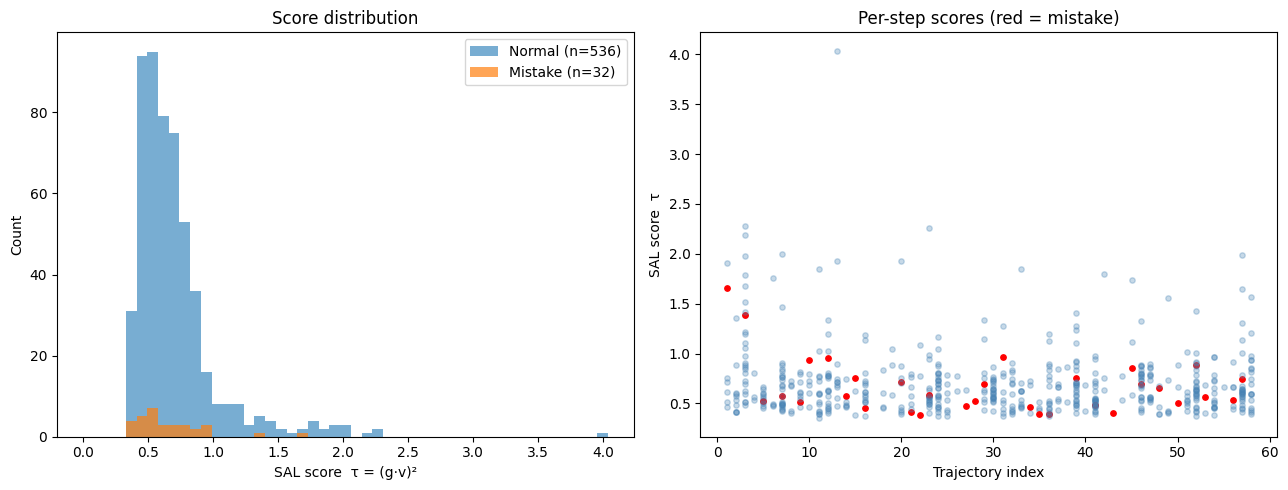

In [14]:
import matplotlib.pyplot as plt
import numpy as np

mistake_rows = [s.row for s in store.index if s.is_mistake]
normal_rows  = [s.row for s in store.index if not s.is_mistake]

mistake_scores = scores[mistake_rows].numpy()
normal_scores  = scores[normal_rows].numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: overlapping histograms ─────────────────────────────────
ax = axes[0]
bins = np.linspace(0, float(scores.max()), 50)
ax.hist(normal_scores,  bins=bins, alpha=0.6, label=f"Normal (n={len(normal_scores)})")
ax.hist(mistake_scores, bins=bins, alpha=0.7, label=f"Mistake (n={len(mistake_scores)})")
ax.set_xlabel("SAL score  τ = (g·v)²")
ax.set_ylabel("Count")
ax.set_title("Score distribution")
ax.legend()

# ── Right: per-trajectory strip plot ─────────────────────────────
ax = axes[1]
for s in store.index:
    color = "red" if s.is_mistake else "steelblue"
    alpha = 1.0  if s.is_mistake else 0.3
    ax.scatter(s.traj_idx, scores[s.row].item(), c=color, s=15, alpha=alpha)

ax.set_xlabel("Trajectory index")
ax.set_ylabel("SAL score  τ")
ax.set_title("Per-step scores (red = mistake)")

fig.tight_layout()
# fig.savefig("/mnt/user-data/outputs/sal_scores.png", dpi=150)
plt.show()